# Implementación de un ARIMA(p,d,q)(P,D,Q) paso a paso

Pronóstico del consúmo eléctrico en California

In [88]:
# Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller


# Modelos ARIMA con stasforecast y statsmodels
from statsforecast import StatsForecast
from statsforecast.models import ARIMA, AutoETS
from pmdarima.arima import nsdiffs


In [89]:
df = pd.read_csv('datos/demanda_electricidad_california.csv')
df

,unique_id,ds,y
0,california,2025-04-27 17:00:00,21997.0
1,california,2025-04-27 18:00:00,21418.0
2,california,2025-04-27 19:00:00,21343.0
3,california,2025-04-27 20:00:00,21908.0
4,california,2025-04-27 21:00:00,22124.0
...,...,...,...
1995,california,2025-07-19 20:00:00,29380.0
1996,california,2025-07-19 21:00:00,27763.0
1997,california,2025-07-19 22:00:00,26659.0
1998,california,2025-07-19 23:00:00,26438.0


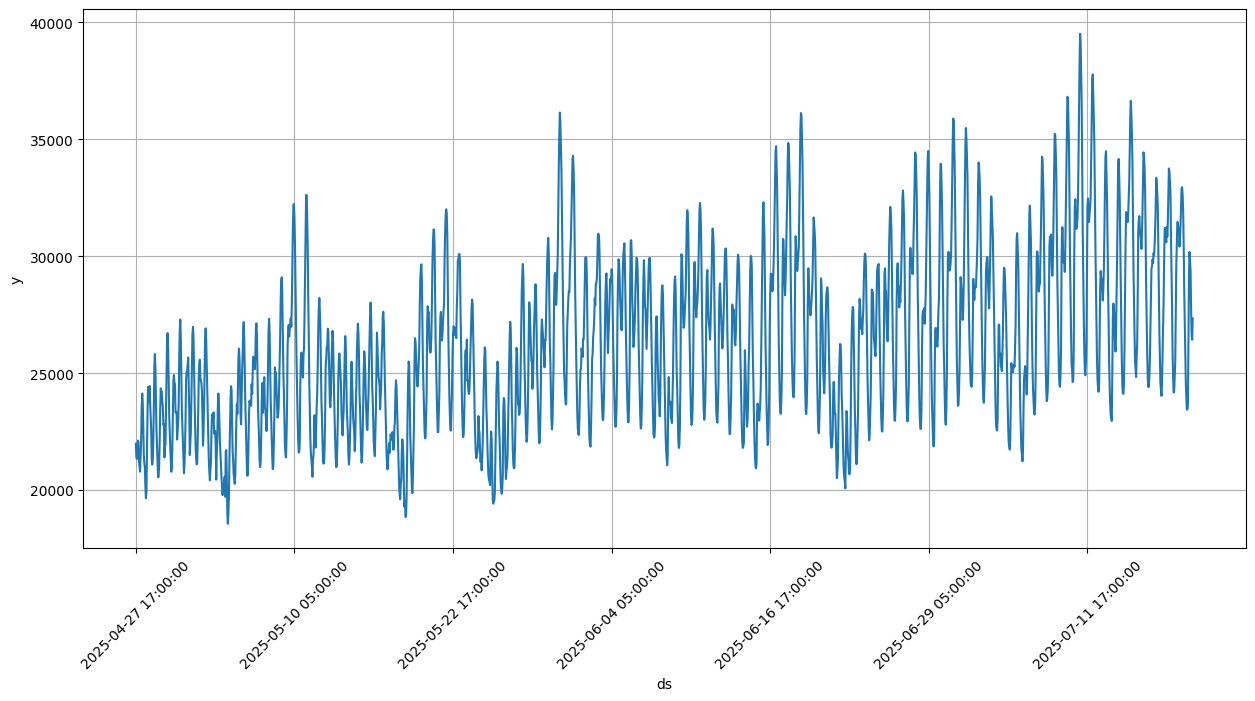

In [90]:
fig, ax =plt.subplots(1, 1, figsize = (15, 7))
sns.lineplot(df, x = 'ds', y = 'y', ax = ax)
ax.grid(True)
ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=8))
plt.xticks(rotation=45)
plt.show()

Se aprecia una serie de tiempo que tiene una ligera tendencia positiva, además, se nota un patrón estacional que, al tratarse de una serie de tiempo de consumo enerético, posiblemente se trata de una periodicidad de 24 horas.

### Modelo Base Suavizado Exponencial

Para hacer un comparativo ,en este caso el modelo base será un modelo de suavizado exponencial con error multiplicativo, tendencia aditiva amortiguada y estacionalidad multiplicativa.

In [91]:
def metricas_cv(cv_df, nombre_modelos):
    resultados = []
    for modelo in nombre_modelos:
        #Agrupar por cutoff y calcular métricas
        metricas_ventana = []
        for cutoff in cv_df['cutoff'].unique():
            ventana = cv_df[cv_df['cutoff'] == cutoff]
            y_true = ventana['y']
            y_pred = ventana[modelo]

            rmse = np.sqrt(np.mean(y_true - y_pred)**2)
            mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
            mae = np.mean(np.abs(y_true - y_pred))

            metricas_ventana.append({'rmse' : rmse, 'mape' : mape, 'mae' : mae})
        
        metricas_df = pd.DataFrame(metricas_ventana)
        resultados.append({
            'Modelo'   : modelo,
            'RMSE'     : metricas_df['rmse'].mean(),
            'MAPE'     : metricas_df['mape'].mean(),
            'MAE'      : metricas_df['mae'].mean(),
            'RMSE_STD' : metricas_df['rmse'].std(),
            'MAPE_STD' : metricas_df['mape'].std(),     
            'MAE_STD'  : metricas_df['mae'].std()    
        })
    df_resultados = pd.DataFrame(resultados)
    df_resultados.index = df_resultados.index + 1
    return df_resultados

* Set de entrenamiento:[:últimas 24 horas]
* Set de prueba       : [últimas 24 horas:]     

In [92]:
df_train = df[:-24].copy()
df_test = df[-24:].copy()
print(df_train.tail(10))
print(df_test.head(10))

       unique_id                   ds        y
1966  california  2025-07-18 15:00:00  25477.0
1967  california  2025-07-18 16:00:00  27766.0
1968  california  2025-07-18 17:00:00  29634.0
1969  california  2025-07-18 18:00:00  30628.0
1970  california  2025-07-18 19:00:00  31468.0
1971  california  2025-07-18 20:00:00  31447.0
1972  california  2025-07-18 21:00:00  31102.0
1973  california  2025-07-18 22:00:00  31182.0
1974  california  2025-07-18 23:00:00  30418.0
1975  california  2025-07-19 00:00:00  30741.0
       unique_id                   ds        y
1976  california  2025-07-19 01:00:00  31331.0
1977  california  2025-07-19 02:00:00  32114.0
1978  california  2025-07-19 03:00:00  32908.0
1979  california  2025-07-19 04:00:00  32959.0
1980  california  2025-07-19 05:00:00  32605.0
1981  california  2025-07-19 06:00:00  31926.0
1982  california  2025-07-19 07:00:00  30425.0
1983  california  2025-07-19 08:00:00  28522.0
1984  california  2025-07-19 09:00:00  27161.0
1985  califor

## Suavizado exponencial

In [93]:
# Instancia del modelo base
modelo_base = [AutoETS(season_length=24, model='MAM', damped=True, alias='modelo_base')]
sf = StatsForecast(
    models=modelo_base,
    freq='h',  # horas
    n_jobs=-1
)

# Validación cruzada: 10 ventanas de tamaño fijo
cv_df = sf.cross_validation(
    df=df_train,
    h=24, # Horizonte del pronóstico
    step_size=24, # Entre ventanas consecutivas saltar 24 horas
    n_windows=10, # 10 ventanas
)

# Desempeño
metricas_modelo_base = metricas_cv(cv_df, ['modelo_base'])
metricas_modelo_base

,Modelo,RMSE,MAPE,MAE,RMSE_STD,MAPE_STD,MAE_STD
1,modelo_base,1179.002313,4.504568,1363.531364,596.835289,1.863908,487.441073


## SARIMA

In [94]:
def prueba_diferenciacion(serie, d, D, m):
    serie = serie.dropna()

    if d != 0:
        for _ in range(d):
            serie = serie.diff()
    
    if D != 0:
        for _ in range(D):
            serie = serie.diff(m)
    
    resultado_estacionario = adfuller(serie.dropna())
    pvaladfuller = resultado_estacionario[1]

    print('>Prueba Estacionariedad con Dickey-Fuller')
    if pvaladfuller < 0.05:
        print('Rechazar H0: Serie Estacionaria')
        print(f'pval: {pvaladfuller:.4f} < 0.05')
        print('Ya no es necesario diferenciar más')
    else:
        print('Aceptar H0: Serie No Estacionaria')
        print(f'pval: {pvaladfuller:.4f} > 0.05')
        print('Diferenciar nuevamente')

    D_necesaria = nsdiffs(serie.dropna(), m=m, test='ch') 

    print('\n>Prueba Estacionalidad con Canova‑Hansen')
    if D_necesaria > 0:
        print("La serie presenta un patrón estacional")
    else:
        print("Puede no haber un patrón estacional")

    fig, ax = plt.subplots(1, 1, figsize = (15, 5))
    plt.plot(range(1, len(serie)+1), serie)
    plt.hlines(serie.mean(), xmin = 1, xmax = len(serie)+1, color = 'red', label = 'Media', linestyle = '--')
    plt.title(f'Serie d = {d}, D = {D}, m = {m}')
    plt.xlabel('Tiempo')
    plt.ylabel('Valor')
    plt.legend()
    plt.show()


>Prueba Estacionariedad con Dickey-Fuller
Aceptar H0: Serie No Estacionaria
pval: 0.0564 > 0.05
Diferenciar nuevamente

>Prueba Estacionalidad con Canova‑Hansen
Puede no haber un patrón estacional


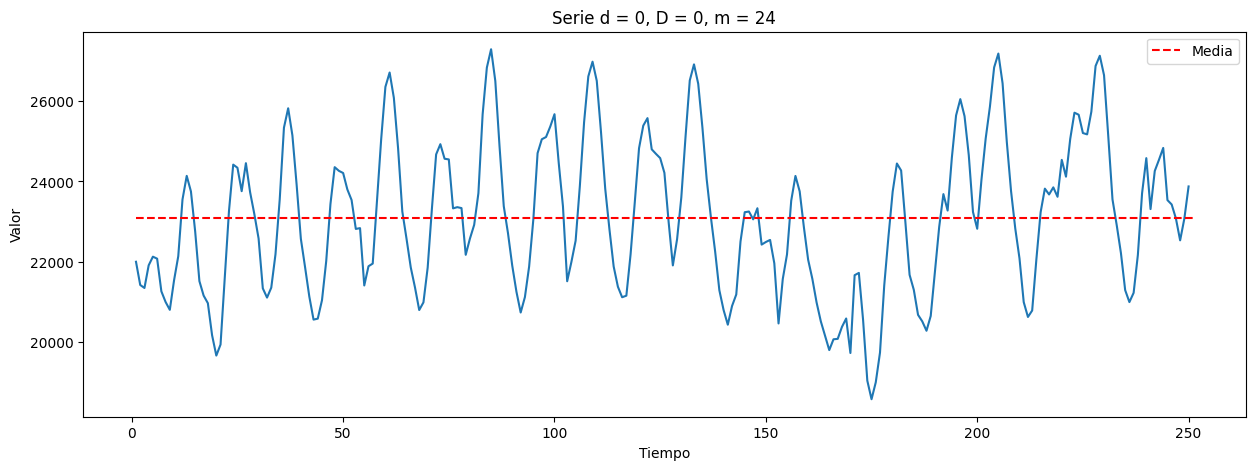

>Prueba Estacionariedad con Dickey-Fuller
Rechazar H0: Serie Estacionaria
pval: 0.0000 < 0.05
Ya no es necesario diferenciar más

>Prueba Estacionalidad con Canova‑Hansen
Puede no haber un patrón estacional


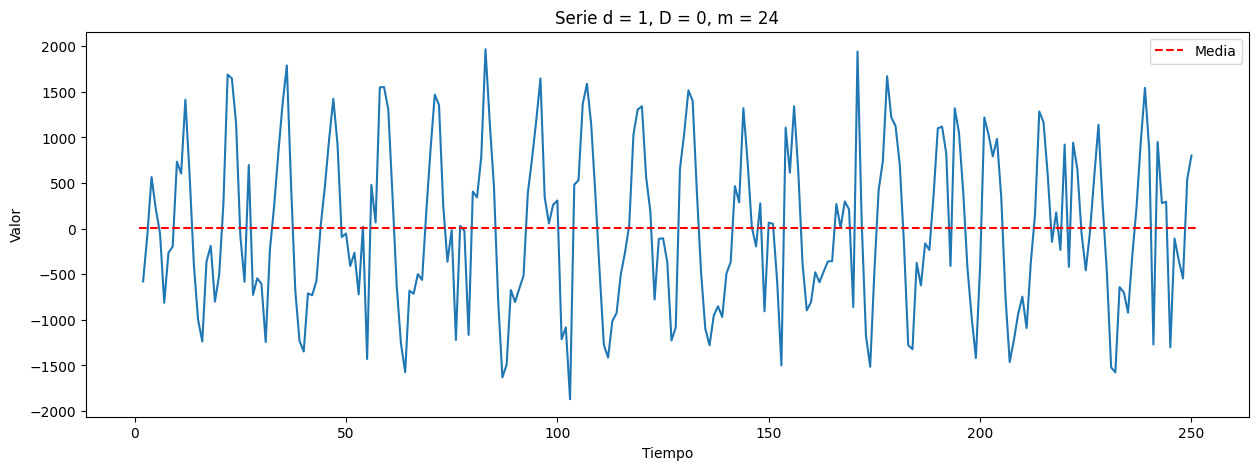

>Prueba Estacionariedad con Dickey-Fuller
Rechazar H0: Serie Estacionaria
pval: 0.0000 < 0.05
Ya no es necesario diferenciar más

>Prueba Estacionalidad con Canova‑Hansen
Puede no haber un patrón estacional


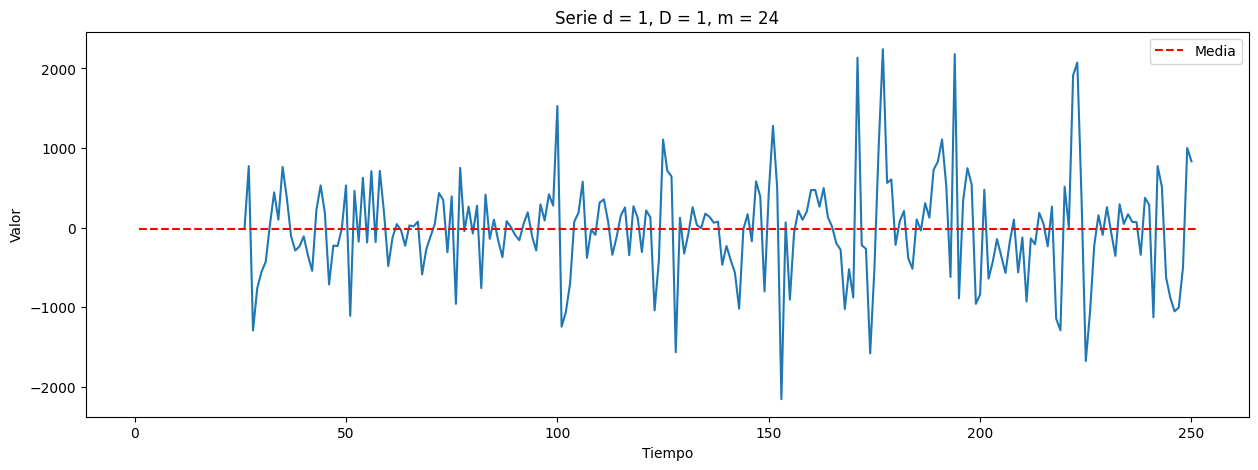

>Prueba Estacionariedad con Dickey-Fuller
Rechazar H0: Serie Estacionaria
pval: 0.0000 < 0.05
Ya no es necesario diferenciar más

>Prueba Estacionalidad con Canova‑Hansen
Puede no haber un patrón estacional


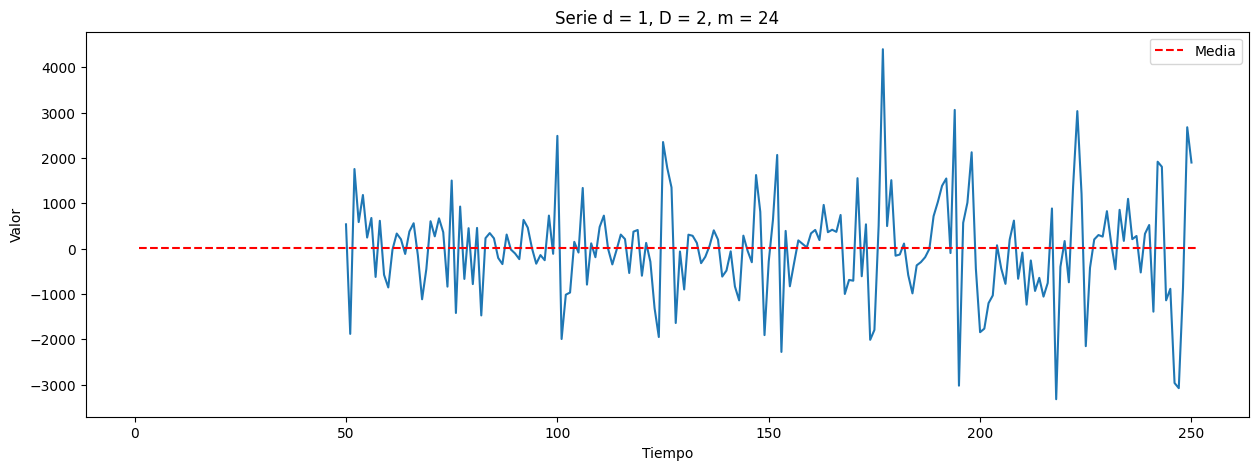

In [95]:
prueba_diferenciacion(df_train['y'][:250], d=0, D=0, m=24)
prueba_diferenciacion(df_train['y'][:250], d=1, D=0, m=24)
prueba_diferenciacion(df_train['y'][:250], d=1, D=1, m=24)
prueba_diferenciacion(df_train['y'][:250], d=1, D=2, m=24)

Una vez identificados los parámetros d = 1 y D = 1, podemos empezar a buscar propuestas para:
* p y P
* q y Q

Pero primero se van a hacer los PACF y ACF de unos parámetros p = 1 y D = 0 para poder observar como el patrón estacional afecta en el comportamiento de las funciónes.

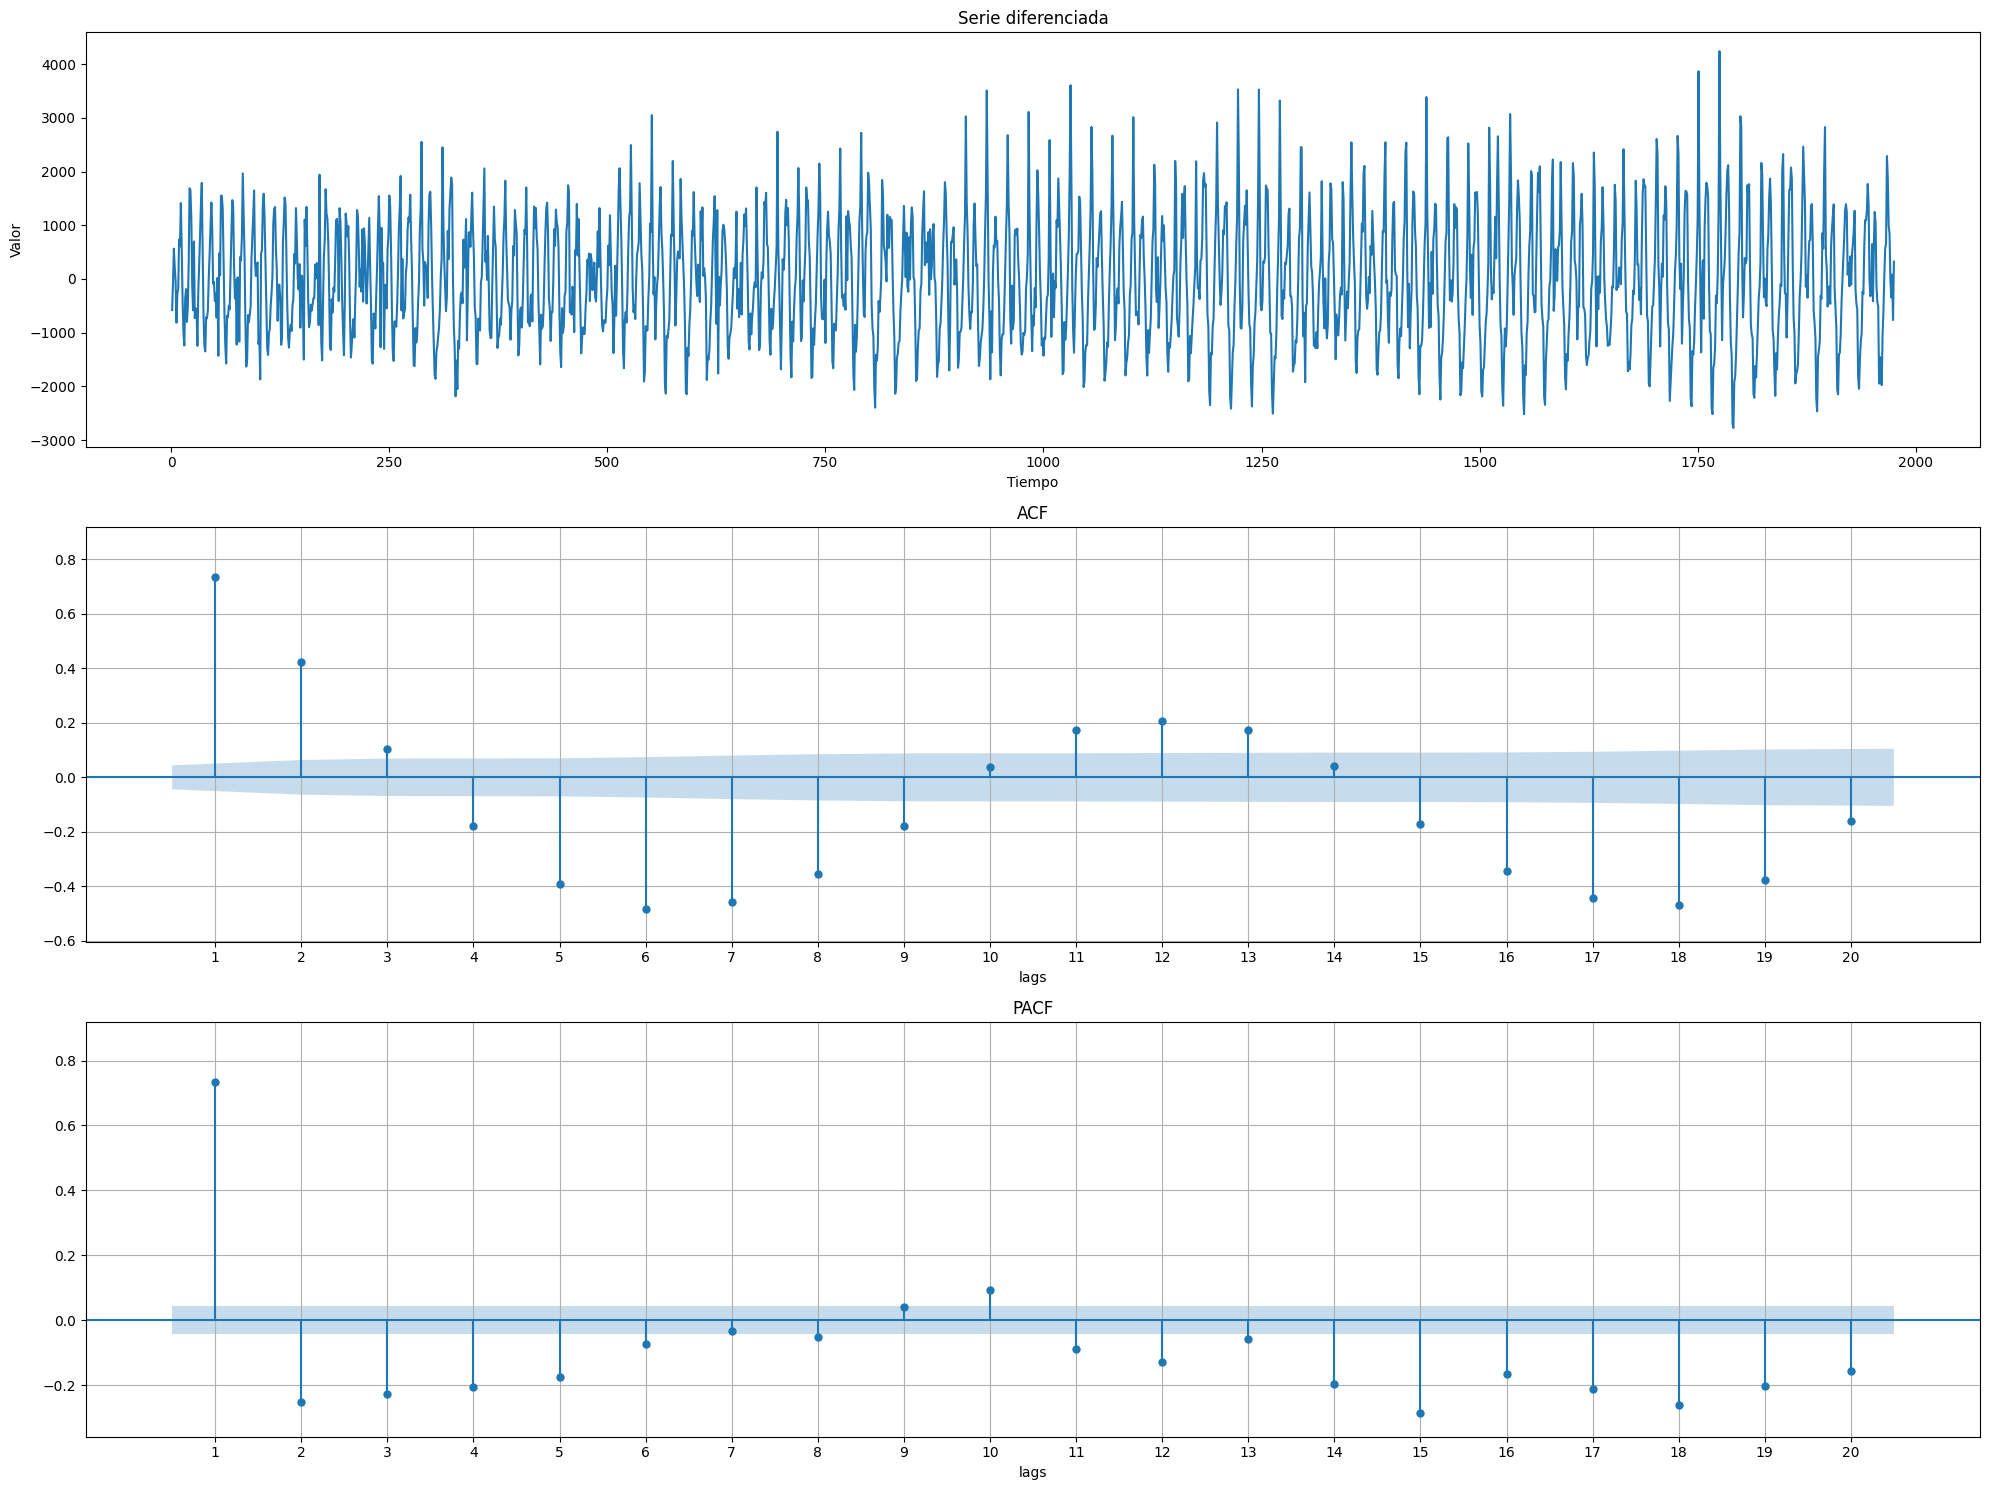

In [96]:
df_dif1 = df_train['y'].diff().dropna()

fig, ax = plt.subplots(3,1, figsize = (20, 15))

sns.lineplot(df_dif1, ax = ax[0])
ax[0].set_title('Serie diferenciada')
ax[0].set_xlabel('Tiempo')
ax[0].set_ylabel('Valor')

LAGS = 20
plot_acf(df_dif1,
        alpha = 0.05,
        lags = LAGS,
        zero = False,
        auto_ylims = True,
        ax = ax[1])
ax[1].set_title('ACF')
ax[1].set_xlabel('lags')
ax[1].set_xticks(range(1, LAGS+1))
ax[1].grid(True)

plot_pacf(df_dif1,
        alpha = 0.05,
        lags = LAGS,
        zero = False,
        auto_ylims = True,
        ax = ax[2])
ax[2].set_title('PACF')
ax[2].set_xlabel('lags')
ax[2].set_xticks(range(1, LAGS+1))
ax[2].grid(True)

plt.tight_layout()

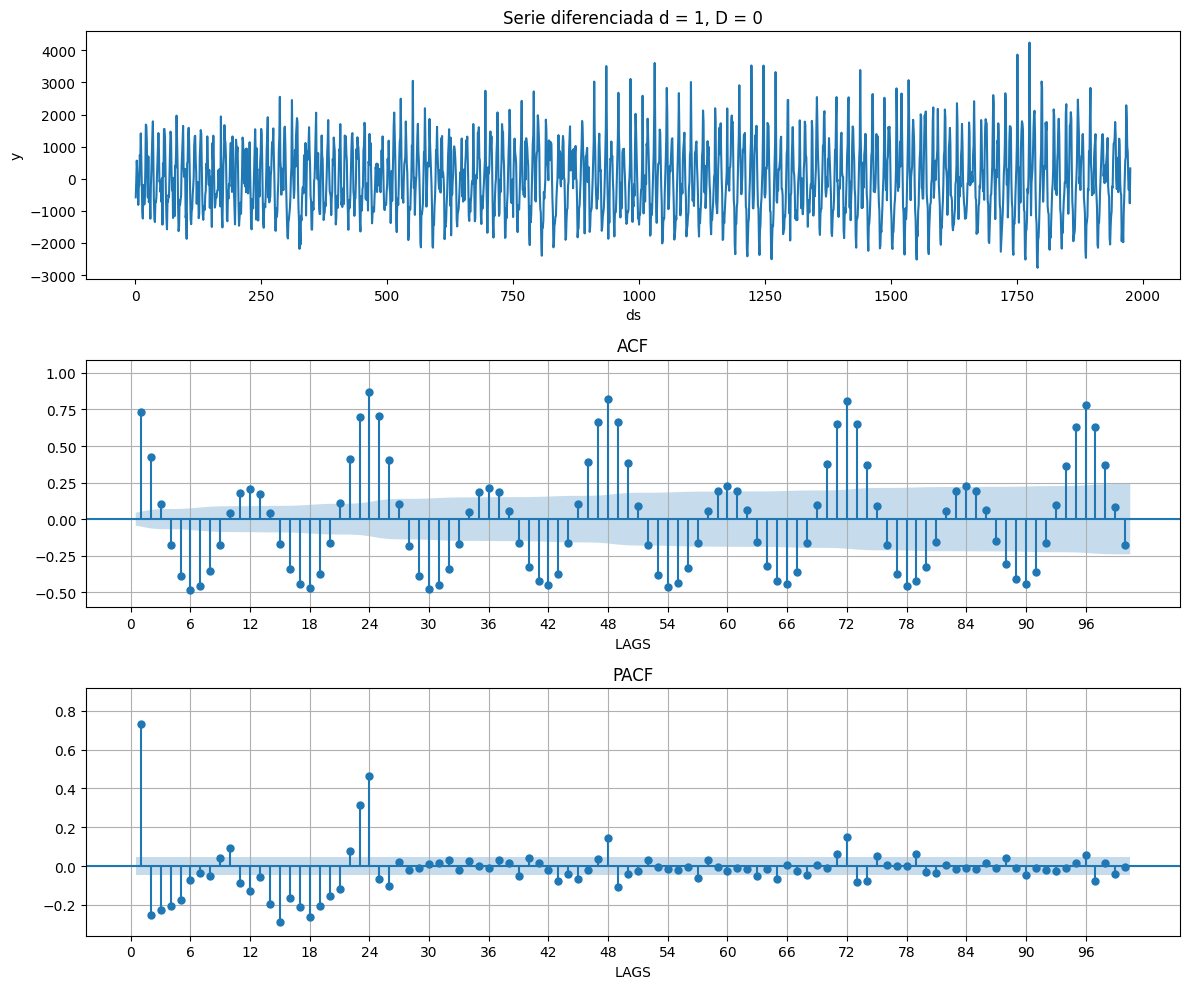

In [97]:
df_diff1 = df_train['y'].diff().dropna()

fig, ax = plt.subplots(3, 1, figsize = (12, 10))

sns.lineplot(df_diff1, ax = ax[0])
ax[0].set_title('Serie diferenciada d = 1, D = 0')
ax[0].set_xlabel('ds')
ax[0].set_ylabel('y')

LAGS = 100
plot_acf(df_diff1,
        alpha=0.05,
        lags = LAGS,
        zero=False,
        auto_ylims=True,
        ax = ax[1])
ax[1].set_title('ACF')
ax[1].set_xlabel('LAGS')
ax[1].set_xticks(range(0, LAGS+1, 6))
ax[1].grid(True)

plot_pacf(df_diff1,
        lags = LAGS,
        zero = False,
        auto_ylims = True,
        ax = ax[2])
ax[2].set_title('PACF')
ax[2].set_xlabel('LAGS')
ax[2].set_xticks(range(0, LAGS+1, 6))
ax[2].grid(True)

plt.tight_layout()


Se pueden ver co,portamientos estacionales que no se desvanecen en el ACF, por lo que si es necesario aplicar un valor diferente de 0 para el parámetro D

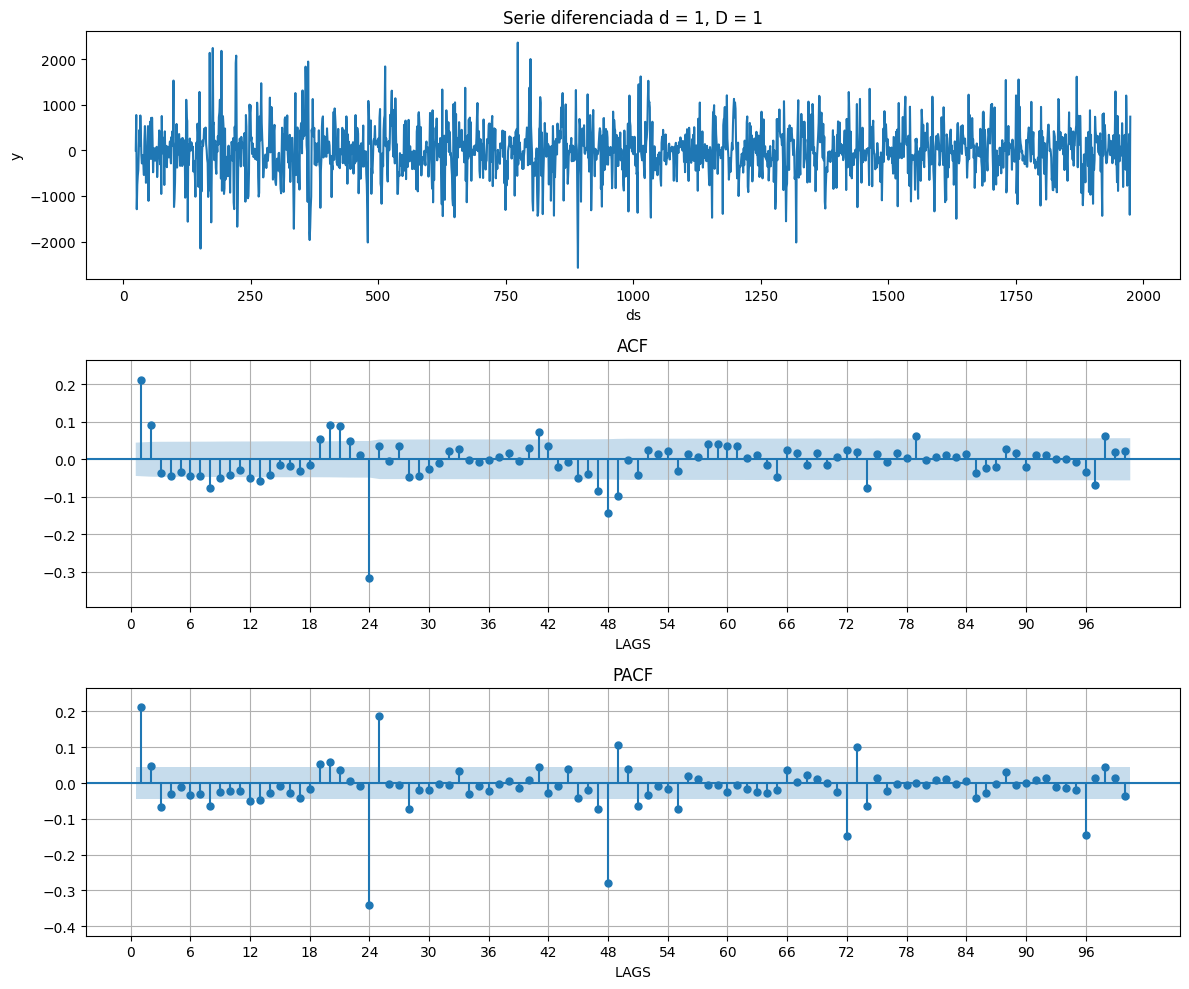

In [98]:
df_diff1 = df_train['y'].diff().dropna()
df_diff1 = df_diff1.diff(24).dropna()

fig, ax = plt.subplots(3, 1, figsize = (12, 10))

sns.lineplot(df_diff1, ax = ax[0])
ax[0].set_title('Serie diferenciada d = 1, D = 1')
ax[0].set_xlabel('ds')
ax[0].set_ylabel('y')

LAGS = 100
plot_acf(df_diff1,
        alpha=0.05,
        lags = LAGS,
        zero=False,
        auto_ylims=True,
        ax = ax[1])
ax[1].set_title('ACF')
ax[1].set_xlabel('LAGS')
ax[1].set_xticks(range(0, LAGS+1, 6))
ax[1].grid(True)

plot_pacf(df_diff1,
        lags = LAGS,
        zero = False,
        auto_ylims = True,
        ax = ax[2])
ax[2].set_title('PACF')
ax[2].set_xlabel('LAGS')
ax[2].set_xticks(range(0, LAGS+1, 6))
ax[2].grid(True)

plt.tight_layout()

Para la ACF:
* q: En el lag 1 y 2 podemos observar valores diferentes de 0 que podrían ser utilizados
* Q: En los múltiplos enteros de 24, encontramos que los valores de 1 y tal vez el 2 se pueden encontrar buenas opciones


Para la PACF
* p: El primer componente parece ser el indicado a usar como parámetro
* P: En múltiplos de 24 se podría usar la opción 1 y 2, pero posteriormente no hay una caída abrupta en posteriores, así que se descarta este hiperparámetro

### Selección del mejor modelo SARIMA

In [99]:
p, d, qs = 1, 1, [1, 2]
P, D, Qs = 0, 1, [1, 2]

modelos = [ARIMA(order=(p, d, q), seasonal_order=(P, D, Q), season_length=24, alias=f'ARIMA({p},{d},{q})({P},{D},{Q})_24', include_constant=False) for q in qs for Q in Qs] 

sf = StatsForecast(
    models = modelos,
    freq = 'h',
    n_jobs = -1
)

print(f'Se crearon {len(modelos)} modelos')
modelos

Se crearon 4 modelos


[ARIMA(1,1,1)(0,1,1)_24,
 ARIMA(1,1,1)(0,1,2)_24,
 ARIMA(1,1,2)(0,1,1)_24,
 ARIMA(1,1,2)(0,1,2)_24]

### Validación cruzada

In [100]:
cv_df = sf.cross_validation(
    df = df_train,
    h = 24,
    step_size = 24, 
    n_windows = 10
)
print(cv_df)

      unique_id                  ds     cutoff        y  \
0    california 2025-07-09 01:00:00 2025-07-09  32028.0   
1    california 2025-07-09 02:00:00 2025-07-09  33660.0   
2    california 2025-07-09 03:00:00 2025-07-09  35238.0   
3    california 2025-07-09 04:00:00 2025-07-09  35203.0   
4    california 2025-07-09 05:00:00 2025-07-09  34459.0   
..          ...                 ...        ...      ...   
235  california 2025-07-18 20:00:00 2025-07-18  31447.0   
236  california 2025-07-18 21:00:00 2025-07-18  31102.0   
237  california 2025-07-18 22:00:00 2025-07-18  31182.0   
238  california 2025-07-18 23:00:00 2025-07-18  30418.0   
239  california 2025-07-19 00:00:00 2025-07-18  30741.0   

     ARIMA(1,1,1)(0,1,1)_24  ARIMA(1,1,1)(0,1,2)_24  ARIMA(1,1,2)(0,1,1)_24  \
0              31697.049287            31628.630112            31728.839015   
1              33554.404652            33447.277214            33613.125799   
2              34840.120140            34726.596676   

In [ ]:
alias_modelos = [m.alias for m in modelos]
metricas_sarimas = metricas_cv(cv_df, alias_modelos)
metricas_sarimas

,Modelo,RMSE,MAPE,MAE,RMSE_STD,MAPE_STD,MAE_STD
1,"ARIMA(1,1,1)(0,1,1)_24",1203.939052,5.033554,1451.630603,1241.698887,3.713008,1068.213152
2,"ARIMA(1,1,1)(0,1,2)_24",1201.357006,4.817195,1397.530570,1129.229760,3.426555,989.195719
3,"ARIMA(1,1,2)(0,1,1)_24",1183.354487,4.957290,1428.763728,1221.392535,3.661863,1053.825895
4,"ARIMA(1,1,2)(0,1,2)_24",1173.581875,4.748453,1377.214361,1128.706848,3.411308,985.322855


El mejor modelo es el **ARIMA(1,1,2)(0,1,2)_24** teniendo:
* RMSE = 1173.581875 +- 1128.706848
* MAPE = 14.748453 +- 3.411308
* MAE = 1377.214361 +- 985.322855

In [102]:
metricas_modelo_base

,Modelo,RMSE,MAPE,MAE,RMSE_STD,MAPE_STD,MAE_STD
1,modelo_base,1179.002313,4.504568,1363.531364,596.835289,1.863908,487.441073


Se tiene un desempeño similar con el modelo base de suavizado exponencial, con RMSE ligeramente menor, pero con mayor variabilidad

### Pronósticos con el modelo seleccionado  **ARIMA(1,1,2)(0,1,2)_24** 

* Pronósticos a 24 horas
* Comparación con los valores reales
* Comparación con las predicciónes del modelo base

In [103]:
# Instancia del modelo base
modelo_base = [AutoETS(season_length=24, model='MAM', damped=True, alias='modelo_base')]
sf = StatsForecast(
    models=modelo_base,
    freq='h',  # horas
    n_jobs=-1
)

In [104]:
sf = StatsForecast(models=[
                        ARIMA(order = (1, 1, 2), seasonal_order=(0, 1, 2), season_length= 24, alias = f'ARIMA(1, 1, 2)(0, 1, 2)_24', include_constant=False),
                        AutoETS(season_length=24, model = 'MAM', damped = True, alias = 'Modelo Base')],
                freq = 'h'
                )
sf.fit(df_train)

fc = sf.forecast(df = df_train, 
                h = 24,
                level = [90])

In [105]:
fc.head()

,unique_id,ds,"ARIMA(1, 1, 2)(0, 1, 2)_24","ARIMA(1, 1, 2)(0, 1, 2)_24-lo-90","ARIMA(1, 1, 2)(0, 1, 2)_24-hi-90",Modelo Base,Modelo Base-lo-90,Modelo Base-hi-90
0,california,2025-07-19 01:00:00,31671.881983,30955.464683,32388.299282,31913.016371,28774.580371,35051.452371
1,california,2025-07-19 02:00:00,33182.107959,32004.982060,34359.233857,33571.358465,30432.922464,36709.794465
2,california,2025-07-19 03:00:00,34350.016725,32768.507338,35931.526112,34822.159382,31683.723381,37960.595383
3,california,2025-07-19 04:00:00,34229.937045,32321.396797,36138.477294,34794.530741,31656.094740,37932.966743
4,california,2025-07-19 05:00:00,33607.329898,31419.531546,35795.128250,34173.689184,31035.253183,37312.125186


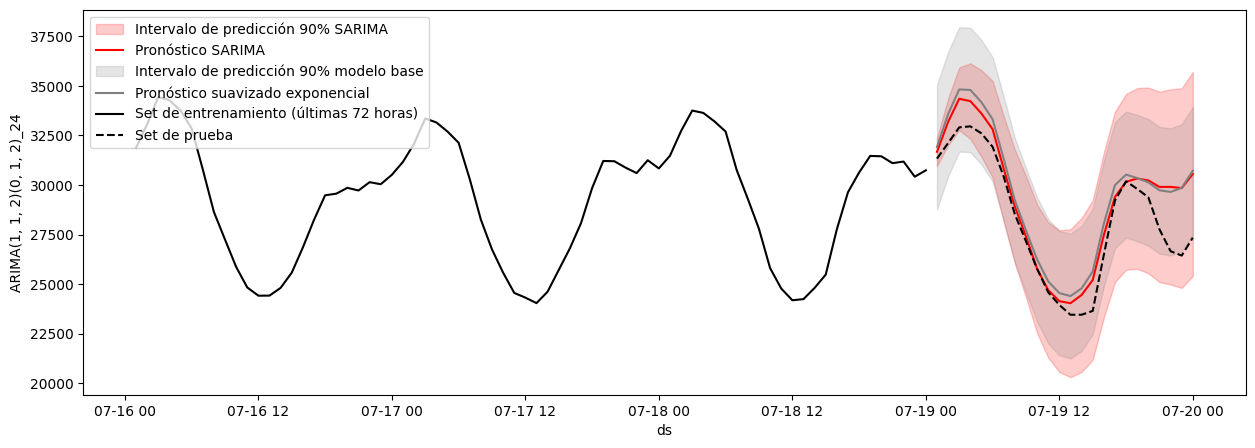

In [116]:
# Graficar
fc["ds"] = pd.to_datetime(fc["ds"])
df_train["ds"] = pd.to_datetime(df_train["ds"])
df_test["ds"] = pd.to_datetime(df_test["ds"])

fig, ax = plt.subplots(figsize = (15, 5))

# SARIMA: pronóstico puntual e intervalo de predicción
plt.fill_between(x=fc["ds"],
                y1 = fc['ARIMA(1, 1, 2)(0, 1, 2)_24-lo-90'],
                y2 = fc['ARIMA(1, 1, 2)(0, 1, 2)_24-hi-90'],
                color = 'red',
                alpha = 0.2,
                label = 'Intervalo de predicción 90% SARIMA')
sns.lineplot(fc, x="ds", y="ARIMA(1, 1, 2)(0, 1, 2)_24", color='red', label='Pronóstico SARIMA')

# Modelo base suavizado exponencial: pronóstico puntual e intervalo de predicción
plt.fill_between(x=fc["ds"],
                y1 = fc['Modelo Base-lo-90'],
                y2 = fc['Modelo Base-hi-90'],
                color = 'gray',
                alpha = 0.2,
                label = 'Intervalo de predicción 90% modelo base');
sns.lineplot(fc, x="ds", y="Modelo Base", color='gray', label='Pronóstico suavizado exponencial')

# Set de entrenamiento (últimas 72 horas) y set de prueba
sns.lineplot(df_train[-24*3:], x="ds", y="y", label='Set de entrenamiento (últimas 72 horas)', color = 'black')
sns.lineplot(df_test, x="ds", y="y", label='Set de prueba', color='black', linestyle='--')
ax.legend(loc = 'upper left')

El modelo ARIMA se ajusta mejor dentro de las primeras 24 horas, además, el inervalo de predicción se ensancha en comparación con el modelo base.

En un inicio los pronósticos van a ser bastante cercanos a la demánda energética real, pero posteriormente los errores se incrementan.